In [67]:
from OceanDataStore import OceanDataCatalog
from nemo_cookbook import NEMODataTree
import gsw
import xarray as xr
import os 
import dask 
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import pandas as pd

from helper_function import solve_vertical_modes
from scipy.linalg import eigh
from scipy import integrate
from xarray_einstats.linalg import solve
import seaborn as sns

In [2]:
# dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
#                  'local_directory': f"{os.getcwd()}/dask_tmp"
#                  })

# # Create Local Cluster:
# cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
# client = Client(cluster)
# client

In [11]:
catalog = OceanDataCatalog(catalog_name="noc-stac") 

ds_domain = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg", consolidated=True, chunks={})

ds_gridT = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})
ds_gridU = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/U1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})
ds_gridV = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})

ds_gridT_y = ds_gridT.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "deptht": 25, "y": 100, "x": 120})
ds_gridT_y["sigma0"] = gsw.density.sigma0(CT=ds_gridT_y["thetao_con"], SA=ds_gridT_y["so_abs"])
ds_gridT_y["sigma0"].name = "sigma0"
ds_gridU_y = ds_gridU.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "depthu": 25, "y": 100, "x": 120})
ds_gridV_y = ds_gridV.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "depthv": 25, "y": 100, "x": 120})

datasets_y = {"parent": {"domain": ds_domain, "gridT": ds_gridT_y, "gridU": ds_gridU_y, "gridV": ds_gridV_y}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo_y = NEMODataTree.from_datasets(datasets=datasets_y, iperio=True, nftype="F", read_mask=True)

# catalog = OceanDataCatalog(catalog_name="noc-stac")

# catalog.search(collection="noc-npd-era5")
# # catalog.available_items

# ds_domain = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/domain/domain_cfg')
# ds_gridT = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/T1m')
# ds_gridU = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/U1m')
# ds_gridV = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/V1m')

# # ds_gridT['sigma0'] = gsw.density.sigma0(CT=ds_gridT['thetao_con'], SA=ds_gridT['so_abs'])
# # ds_gridT['sigma0'].name = 'sigma0'

# datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT, "gridU": ds_gridU, "gridV": ds_gridV}}
# nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

# g = 9.8 # gravity 
# rho_0 = 1026 # reference sea water denisty

# ###
# # overturnign streamfunction #
# ###
# atlmask = ds_domain['atlmsk'].rename({"x":"i", "y":"j"}).astype(bool) # assign to V-grid
# atlmask['i'] = atlmask['i'] + 1
# atlmask['j'] = atlmask['j'] + 1.5
# Psi = nemo_y['gridV/vo'].integral(dims=["i", "k"], cum_dims=["k"], dir="+1", mask=atlmask)
# print('Overturning streamfunciton calculated')

# ###
# # geostorphic compoennt 
# ###
# f_V = ds_domain["ff_f"].rename({"x": "i", "y": "j"}) # corilis parameter on V-grid
# f_V = f_V.assign_coords(i=nemo_y["gridV/vo"].i, j=nemo_y["gridV/vo"].j)

# dsigma_dx = nemo_y["gridT/sigma0"].derivative(dim="i").interp_to(to="V")
# dv_dz = -g * dsigma_dx / (rho_0 * f_V)
# v_g = dv_dz.integral(dims=["k"], cum_dims=["k"], dir="+1")
# v_g_rel = v_g - v_g.isel(k=-1) # zero velocity at depth 

# Psi_geostrophic = ((v_g_rel * nemo_y["gridV/e1v"]).sum(dim="i"))
# Psi_geostrophic = Psi_geostrophic.where(atlmask.any(dim="i"))
# print('Geostrophic streamfunciton calculated')

# ###
# # ekamn compoennt 
# ###
# f_U = ds_domain["ff_f"].rename({"x": "i", "y": "j"})
# f_U = f_U.assign_coords(i=nemo_y["gridU/tauuo"].i, j=nemo_y["gridU/tauuo"].j)
# M_e = nemo_y["gridU/tauuo"] / (rho_0 * f_U)
# Psi_ek = (M_e * nemo_y["gridU/e1u"]).interp_to(to="V").sum(dim="i")
# print('Ekman streamfunciton calculated')

# ###
# # residaul 
# ###
# Psi_residual = Psi - Psi_geostrophic - Psi_ek
# print('Residual streamfunciton calculated')

In [ ]:
###
# reading data #
###
ds_psi = xr.open_dataset("Psij_monthly_130_280_10.nc")
# Psi = ds_psi["integral_ik(vo)"]
climatology = ds_psi.groupby("time_counter.month").mean("time_counter") # remove seasonal climaotlogy from data 
ds_psi_anom = ds_psi.groupby("time_counter.month") - climatology
Psi = ds_psi_anom["integral_ik(vo)"]

# calculating normal modes 
z = Psi.depthv.values # depth points 
ds_N2 = xr.open_dataset("N2_mean.nc").sigma0.values
N2 = -ds_N2 # wronmg sign convention when saving the data

Psi

<xarray.DataArray 'integral_ik(vo)' (time_counter: 577, k: 75, j: 31)> Size: 11MB
array([[[ 0.00000000e+00,  2.87667115e-02, -1.81935565e-02, ...,
         -6.86834472e-03, -7.32793801e-03,  7.79396049e-03],
        [ 0.00000000e+00,  5.96678650e-02, -3.71560779e-02, ...,
         -1.37238452e-02, -1.50057279e-02,  1.62165128e-02],
        [ 0.00000000e+00,  9.36599488e-02, -5.74160615e-02, ...,
         -2.07339461e-02, -2.32627217e-02,  2.52154383e-02],
        ...,
        [ 0.00000000e+00,  2.79083068e-01,  2.70461392e-01, ...,
          7.48989366e-02,  5.67429476e-02,  7.31295568e-02],
        [ 0.00000000e+00,  2.79083068e-01,  2.70461392e-01, ...,
          7.48989366e-02,  5.67429476e-02,  7.31295568e-02],
        [ 0.00000000e+00,  2.79083068e-01,  2.70461392e-01, ...,
          7.48989366e-02,  5.67429476e-02,  7.31295568e-02]],

       [[ 0.00000000e+00, -4.46387236e-02, -5.39840451e-02, ...,
          8.06689824e-03,  2.08831621e-02,  2.93383853e-02],
        [ 0.00000000e+00, -9.25565996e-02, -1.11702560e-01, ...,
          1.64888248e-02,  4.22803917e-02,  5.93375928e-02],
        [ 0.00000000e+00, -1.44476484e-01, -1.73546981e-01, ...,
          2.52453533e-02,  6.42314819e-02,  8.99396238e-02],
...
          1.11900146e+00,  1.15105792e+00,  1.14776364e+00],
        [ 0.00000000e+00,  9.39959963e-01,  9.39044122e-01, ...,
          1.11900146e+00,  1.15105792e+00,  1.14776364e+00],
        [ 0.00000000e+00,  9.39959963e-01,  9.39044122e-01, ...,
          1.11900146e+00,  1.15105792e+00,  1.14776364e+00]],

       [[ 0.00000000e+00, -4.56899216e-02, -5.62238690e-03, ...,
         -1.16447923e-02, -1.57716842e-04,  5.47981213e-03],
        [ 0.00000000e+00, -9.49736901e-02, -1.15052976e-02, ...,
         -2.41688777e-02, -6.56805508e-04,  1.07951135e-02],
        [ 0.00000000e+00, -1.48705851e-01, -1.77536762e-02, ...,
         -3.76752824e-02, -1.44053076e-03,  1.59738289e-02],
        ...,
        [ 0.00000000e+00, -1.38580571e-01, -8.74847963e-02, ...,
         -1.72333913e-01, -2.74772245e-01, -2.92344744e-01],
        [ 0.00000000e+00, -1.38580571e-01, -8.74847963e-02, ...,
         -1.72333913e-01, -2.74772245e-01, -2.92344744e-01],
        [ 0.00000000e+00, -1.38580571e-01, -8.74847963e-02, ...,
         -1.72333913e-01, -2.74772245e-01, -2.92344744e-01]]],
      shape=(577, 75, 31))
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:00 ... ...
    time_centered  (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:00 ... ...
    month          (time_counter) int64 5kB 1 2 3 4 5 6 7 8 ... 7 8 9 10 11 12 1
  * k              (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
    depthv         (k) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * j              (j) float64 248B 131.5 136.5 141.5 ... 271.5 276.5 281.5
Attributes:
    interval_operation:  1 month
    long_name:           ocean current along j-axis
    online_operation:    average
    standard_name:       sea_water_y_velocity
    interval_write:      1 month
    cell_methods:        time: mean
    units:               m/s

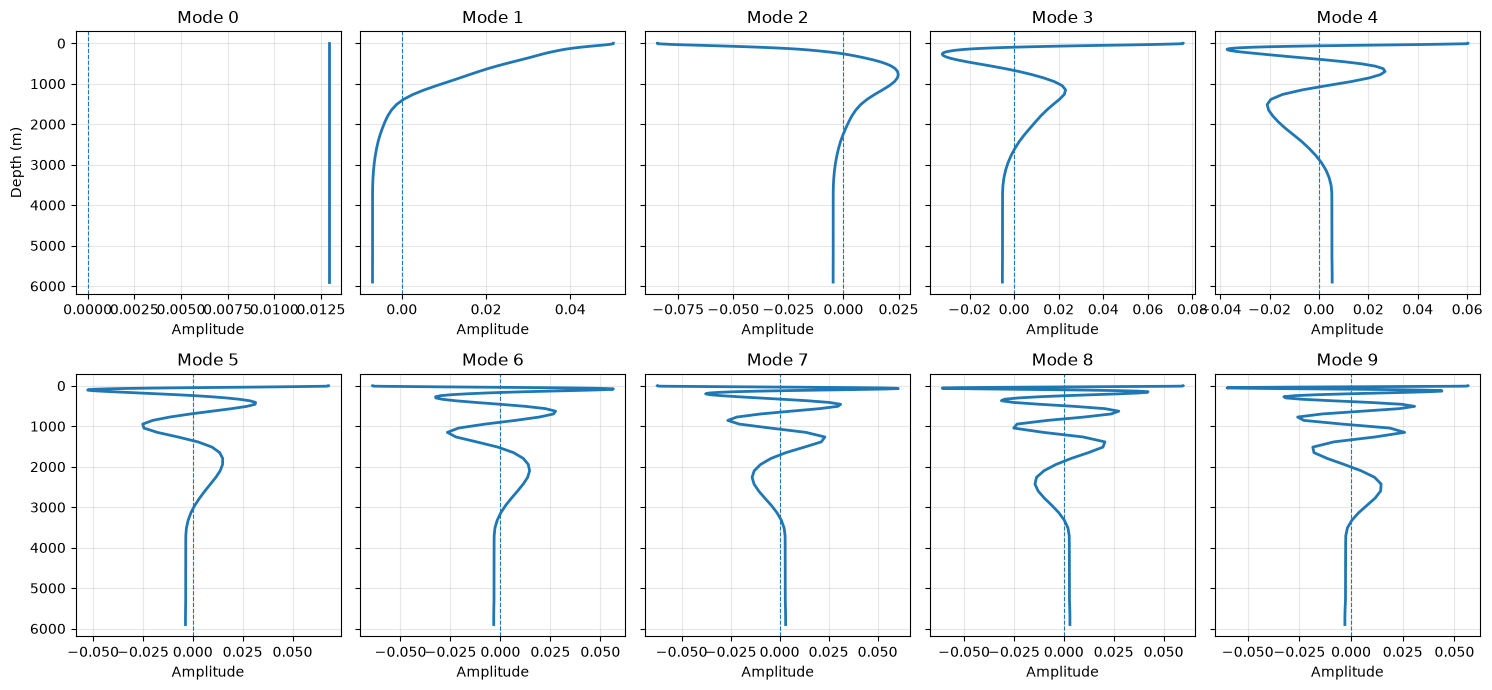

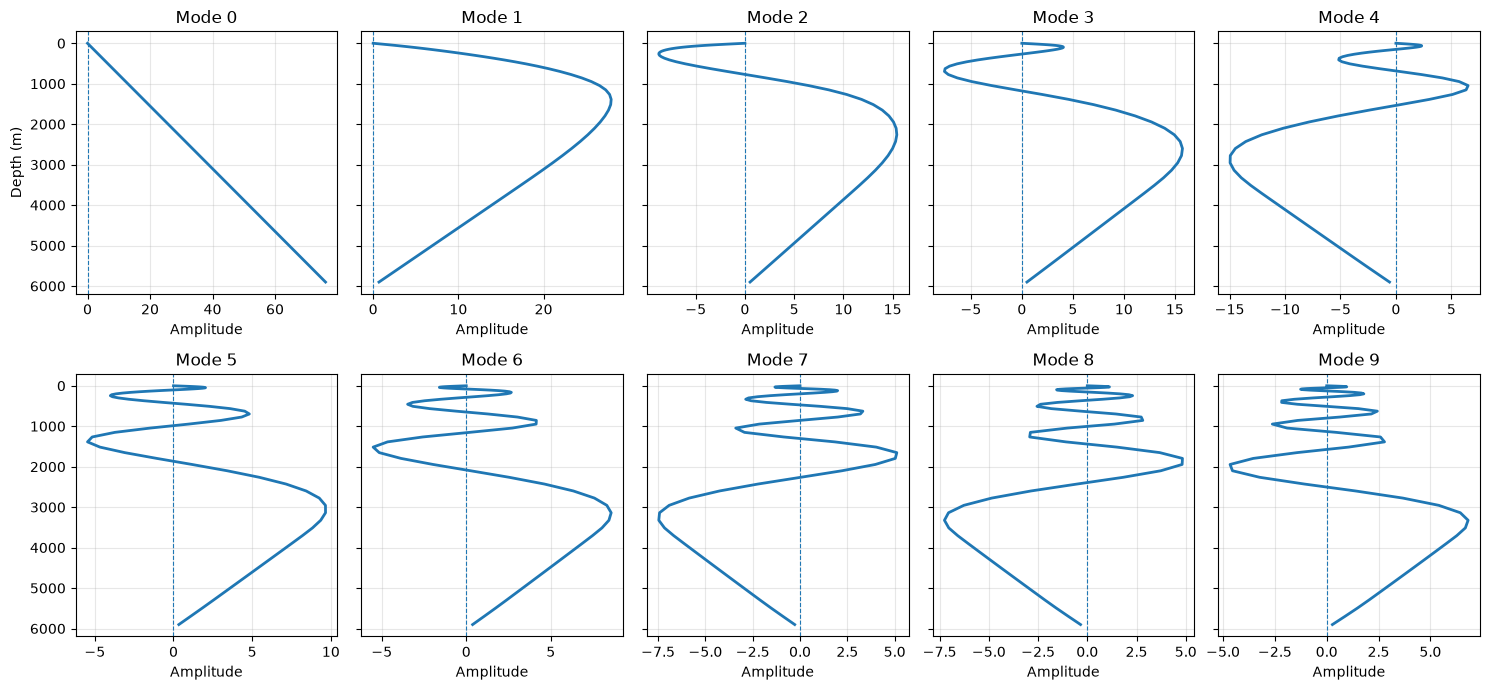

In [16]:
###
# calculating vertical basis #
###
# identify and clean problematic poitns 
N2_clean = N2.copy()
bad = ~np.isfinite(N2_clean) | (N2_clean <= 0)
N2_min = 1e-9
N2_clean[bad] = N2_min
# print("Number of modified points:", bad.sum())
# print("Indices:", np.where(bad)[0])
# print("Original values:", N2_clean[bad])

# calculate normal modes
eigenvals, eigenvecs, B = solve_vertical_modes(N2_clean, z) 
eigenvecs_xr = xr.DataArray(eigenvecs, dims=("k", "mode"), 
    coords={"k": np.arange(1, eigenvecs.shape[0] + 1), "mode": np.arange(1, eigenvecs.shape[1] + 1), "depthv": ("k", Psi.depthv.values)}, 
    name="normal_modes") 
eigvecs_T_xr = xr.DataArray(eigenvecs.T, dims=("mode", "k"), 
    coords={"mode": np.arange(1, eigenvecs.shape[1] + 1), "k": np.arange(1, eigenvecs.shape[0] + 1), "depthv": ("k", Psi.depthv.values)}, 
    name="normal_modes_T") 
B_xr = xr.DataArray(B, dims=("k", "k2"), 
                    coords={"k": np.arange(1, eigenvecs.shape[0] + 1), "k2": np.arange(1, eigenvecs.shape[0] + 1)}, 
                    name="weight_matrix") 
w_xr = xr.DataArray(np.diag(B), dims="k", 
    coords={"k": np.arange(1, eigenvecs.shape[0] + 1)}, name="quadrature_weights")


# plotting 
fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.plot(eigenvecs[:, i], z, linewidth=2)
    ax.axvline(0, linestyle='--', linewidth=0.8)

    ax.set_title(f'Mode {i}')
    ax.set_xlabel('Amplitude')
    ax.grid(True, alpha=0.3)

# Depth only needs to be labelled on the first subplot
axes[0].set_ylabel('Depth (m)')

# If depth increases downward:
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

###
# cumalative vertical integral #
###

integrated_modes = integrate.cumulative_trapezoid(eigenvecs, z, axis=0, initial=0.0)

# plotting 
fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.plot(integrated_modes[:, i], z, linewidth=2)
    ax.axvline(0, linestyle='--', linewidth=0.8)

    ax.set_title(f'Mode {i}')
    ax.set_xlabel('Amplitude')
    ax.grid(True, alpha=0.3)

# Depth only needs to be labelled on the first subplot
axes[0].set_ylabel('Depth (m)')

# If depth increases downward:
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()


cum_eigvecs_xr = xr.DataArray(integrated_modes, dims=("k", "mode"), 
    coords={"k": np.arange(1, eigenvecs.shape[0] + 1), "mode": np.arange(1, eigenvecs.shape[1] + 1), "depthv": ("k", Psi.depthv.values)}, 
    name="cumalative_normal_modes") 
cum_eigenvecs_T_xr = xr.DataArray(integrated_modes.T, dims=("mode", "k"), 
    coords={"mode": np.arange(1, eigenvecs.shape[1] + 1), "k": np.arange(1, eigenvecs.shape[0] + 1), "depthv": ("k", Psi.depthv.values)},
    name="cumalative_normal_modes_T")

# integrated_modes2 = integrate.cumulative_simpson(eigenvecs, x=z, axis=0, initial=0.0)

# # plotting 
# fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
# axes = axes.flatten()
# for i, ax in enumerate(axes):
#     ax.plot(integrated_modes2[:, i], z, linewidth=2)
#     ax.axvline(0, linestyle='--', linewidth=0.8)

#     ax.set_title(f'Mode {i}')
#     ax.set_xlabel('Amplitude')
#     ax.grid(True, alpha=0.3)

# # Depth only needs to be labelled on the first subplot
# axes[0].set_ylabel('Depth (m)')

# # If depth increases downward:
# axes[0].invert_yaxis()

# plt.tight_layout()
# plt.show()

# # plotting 
# fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
# axes = axes.flatten()
# for i, ax in enumerate(axes):
#     ax.plot(eigenvecs[:, i] - integrated_modes[:, i], z, linewidth=2, label="1")
#     ax.plot(eigenvecs[:, i] - integrated_modes2[:, i], z, linewidth=2, label="2")
#     ax.axvline(0, linestyle='--', linewidth=0.8)

#     ax.set_title(f'Mode {i}')
#     ax.set_xlabel('Amplitude')
#     ax.legend()
#     ax.grid(True, alpha=0.3)

# # Depth only needs to be labelled on the first subplot
# axes[0].set_ylabel('Depth (m)')

# # If depth increases downward:
# axes[0].invert_yaxis()

# plt.tight_layout()
# plt.show()

In [30]:
G_xr = cum_eigvecs_xr.rename({"mode": "mode_right"}) # xarray: cumalative normal modes [depth index, mode]
GT_xr = cum_eigvecs_xr.rename({"mode": "mode_left"}) # xarray: transpose of above array [mode, depth_index]
Gram_G_2 = xr.dot(GT_xr, G_xr * w_xr, dims="k") # 

###
# projecting streamfunction onto basis
###

results = []

for j_idx in ds_psi.j.values:
    Q_xr = Psi.sel(j=j_idx).transpose("k", "time_counter") # xarray: streamfunction at specific latitudes [depth_indx, time_counter]

    rhs = xr.dot(GT_xr, Q_xr * w_xr, dims="k")
    
    a = solve(Gram_G_2, rhs, dims=("mode_left", "mode_right"))

    a = a.expand_dims(j=[j_idx])
    results.append(a)

a_all = xr.concat(results, dim="j")
a_10 = a_all.isel(mode_right=np.arange(0,10,1))

print("a_all dims:", a_all.dims)
print("a_all shape:", a_all.shape)


# Gram_G_1 = xr.dot(GT_xr, B_xr, G_xr, dims=["k", "k2"])

# difference = Gram_G_1 - Gram_G_2
# print(float(np.abs(difference).max()))


a_all dims: ('j', 'time_counter', 'mode_right')
a_all shape: (31, 577, 75)


Stats analysis on modes 

Temporal properties:
    Autocorrelation → timescale
    Power spectrum → dominant timescales
    Cross-correlation → lead/lag between modes
    Coherence → which timescales modes interact on

Spatial properties:
    Spatial correlation function → correlation length
    Zero crossing → characteristic spatial scale
    Spatial variance → where each mode is strongest
    Correlation length vs latitude → how scale changes geographically

Mode relationships:
    Mode–mode correlation matrix
    Mode–mode coherence
    PCA/EOF → dominant combinations of modes


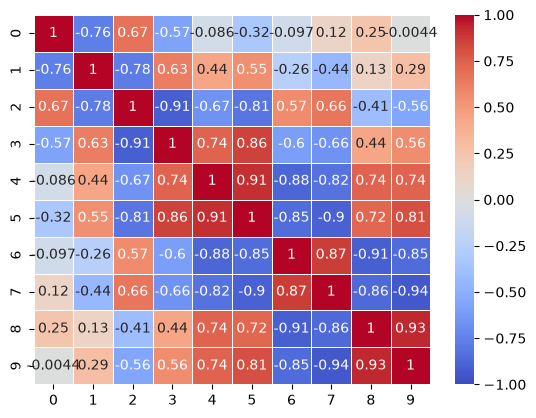

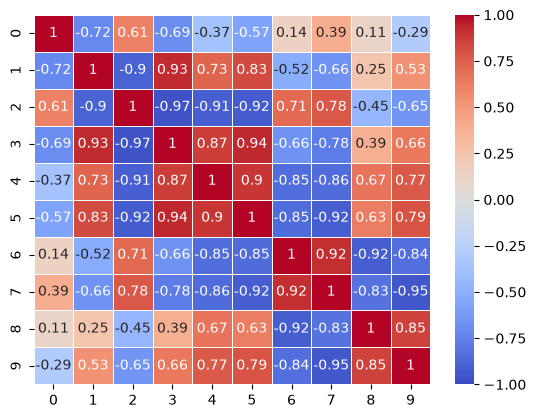

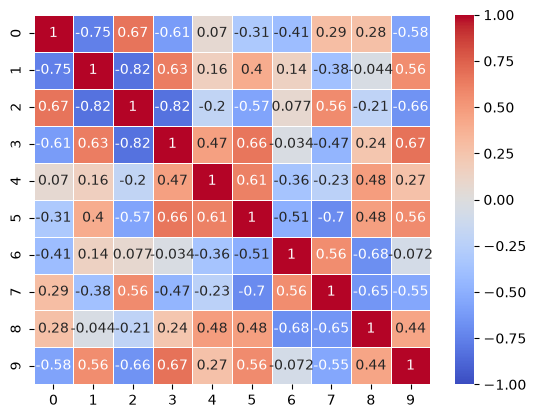

In [ ]:
# How correlated are different modes with each other at a fixed latitude?

j_index = 15
n_modes = 10
correlation_matrix = np.zeros((n_modes, n_modes))

for mode_1 in range(n_modes):
    signal_1 = a_10.isel(
        mode_right=mode_1,
        j=j_index
    ).values

    for mode_2 in range(n_modes):
        signal_2 = a_10.isel(
            mode_right=mode_2,
            j=j_index
        ).values

        correlation_matrix[mode_1, mode_2] = np.corrcoef(
            signal_1, signal_2
        )[0, 1]

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.show()

j_index = 1
n_modes = 10
correlation_matrix = np.zeros((n_modes, n_modes))

for mode_1 in range(n_modes):
    signal_1 = a_10.isel(
        mode_right=mode_1,
        j=j_index
    ).values

    for mode_2 in range(n_modes):
        signal_2 = a_10.isel(
            mode_right=mode_2,
            j=j_index
        ).values

        correlation_matrix[mode_1, mode_2] = np.corrcoef(
            signal_1, signal_2
        )[0, 1]

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.show()

j_index = 30
n_modes = 10
correlation_matrix = np.zeros((n_modes, n_modes))

for mode_1 in range(n_modes):
    signal_1 = a_10.isel(
        mode_right=mode_1,
        j=j_index
    ).values

    for mode_2 in range(n_modes):
        signal_2 = a_10.isel(
            mode_right=mode_2,
            j=j_index
        ).values

        correlation_matrix[mode_1, mode_2] = np.corrcoef(
            signal_1, signal_2
        )[0, 1]

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.show()

/home/teaching/StreamfunctionReconstruction/venv/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/teaching/StreamfunctionReconstruction/venv/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


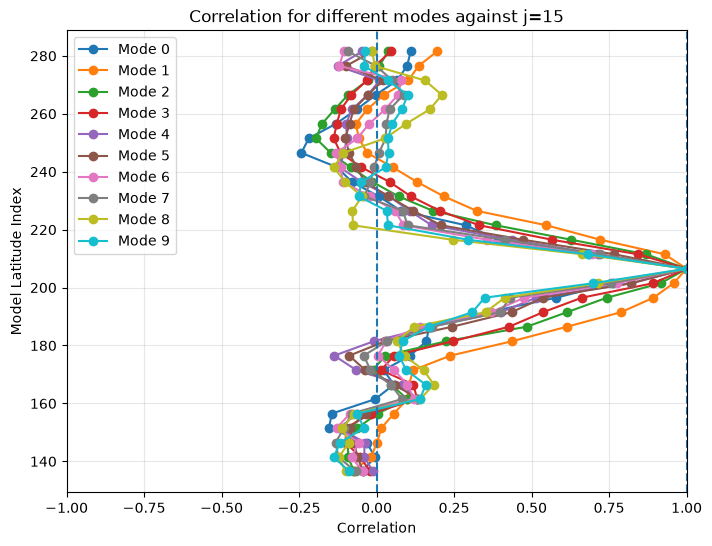

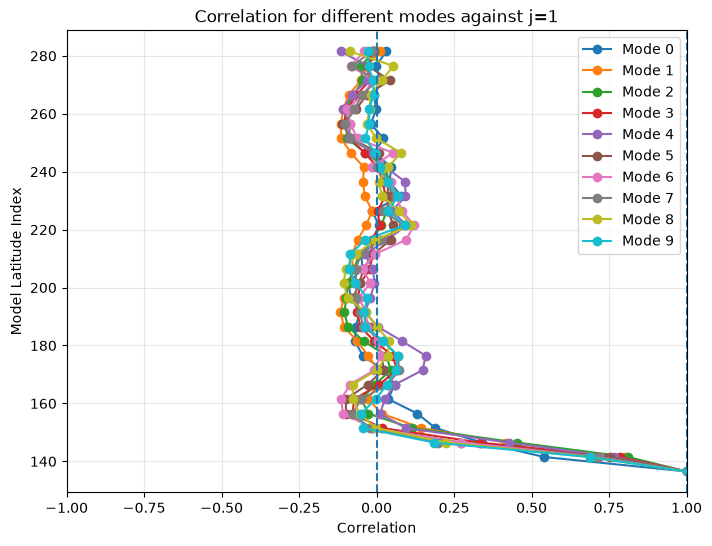

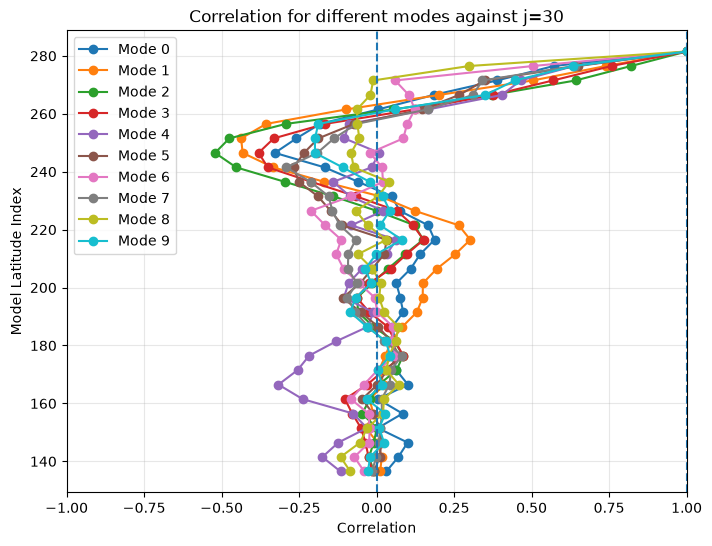

In [74]:
# How correlated is a fixed mode to the same mode at other latitudes?

plt.figure(figsize=(8, 6))

reference_j = 15

for mode_number in range(10):

    # choose which mode we want to compare across latitudes: mode 1/ mode 2 ... etc.
    mode = a_10.isel(mode_right=mode_number)
    # mode x at reference latitude - RAPID-ish
    signal_1 = mode.isel(j=reference_j).values
    # calculate correlation between mode x at reference latitude and all other latitudes 
    correlations_results = []
    for j in mode.j.values:
        signal_2 = mode.sel(j=j).values
        r = np.corrcoef(signal_1, signal_2)[0, 1]
        correlations_results.append(r)

    plt.plot(correlations_results, mode.j.values, marker = "o", label=f"Mode {mode_number}")

plt.xlabel("Correlation")
plt.ylabel("Model Latitude Index")
plt.xlim(-1, 1)
plt.axvline(0, linestyle='--')
plt.axvline(1, linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f"Correlation for different modes against j={reference_j}")
plt.show()

plt.figure(figsize=(8, 6))
reference_j = 1
for mode_number in range(10):
    # choose which mode we want to compare across latitudes: mode 1/ mode 2 ... etc.
    mode = a_10.isel(mode_right=mode_number)
    # mode x at reference latitude - RAPID-ish
    signal_1 = mode.isel(j=reference_j).values
    # calculate correlation between mode x at reference latitude and all other latitudes 
    correlations_results = []
    for j in mode.j.values:
        signal_2 = mode.sel(j=j).values
        r = np.corrcoef(signal_1, signal_2)[0, 1]
        correlations_results.append(r)
    plt.plot(correlations_results, mode.j.values, marker = "o", label=f"Mode {mode_number}")

plt.xlabel("Correlation")
plt.ylabel("Model Latitude Index")
plt.xlim(-1, 1)
plt.axvline(0, linestyle='--')
plt.axvline(1, linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f"Correlation for different modes against j={reference_j}")
plt.show()


plt.figure(figsize=(8, 6))
reference_j = j=30
for mode_number in range(10):
    # choose which mode we want to compare across latitudes: mode 1/ mode 2 ... etc.
    mode = a_10.isel(mode_right=mode_number)
    # mode x at reference latitude - RAPID-ish
    signal_1 = mode.isel(j=reference_j).values
    # calculate correlation between mode x at reference latitude and all other latitudes 
    correlations_results = []
    for j in mode.j.values:
        signal_2 = mode.sel(j=j).values
        r = np.corrcoef(signal_1, signal_2)[0, 1]
        correlations_results.append(r)

    plt.plot(correlations_results, mode.j.values, marker = "o", label=f"Mode {mode_number}")

plt.xlabel("Correlation")
plt.ylabel("Model Latitude Index")
plt.xlim(-1, 1)
plt.axvline(0, linestyle='--')
plt.axvline(1, linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(f"Correlation for different modes against j={reference_j}")
plt.show()

/tmp/ipykernel_42714/1618609519.py:25: RuntimeWarning: Mean of empty slice
  correlations.append(np.nanmean(lag_correlations))


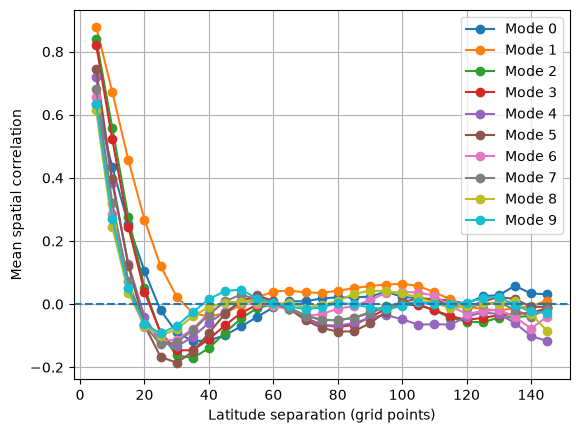

In [ ]:
# at what distance do the same modes stop being correlated with each other?
for mode_number in range(10):
    # choose mode x
    mode = a_10.isel(mode_right=mode_number)

    correlations = []
    separations = []

    j_values = mode.j.values

    # Separation in index space
    for lag in range(1, len(j_values)):

        lag_correlations = []

        for j in range(len(j_values) - lag):

            signal_1 = mode.isel(j=j).values
            signal_2 = mode.isel(j=j + lag).values

            r = np.corrcoef(signal_1, signal_2)[0, 1]

            lag_correlations.append(r)

        # Average correlation for this separation
        correlations.append(np.nanmean(lag_correlations))
        separation = j_values[lag] - j_values[0]
        separations.append(separation)

    plt.plot(separations, correlations, marker="o", label=f"Mode {mode_number}")

plt.axhline(0, linestyle="--")
plt.xlabel("Latitude separation (grid points)")
plt.ylabel("Mean spatial correlation")
plt.legend()
plt.grid()
plt.show()

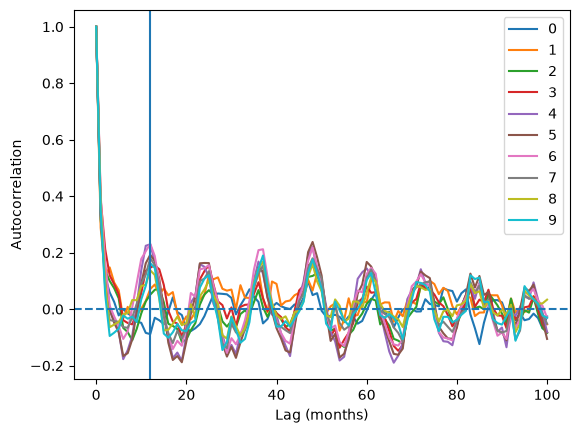

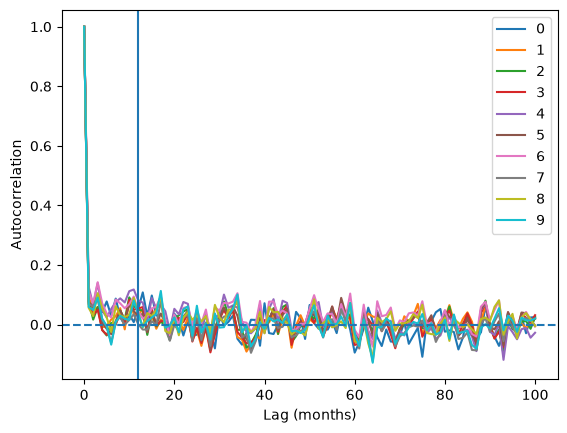

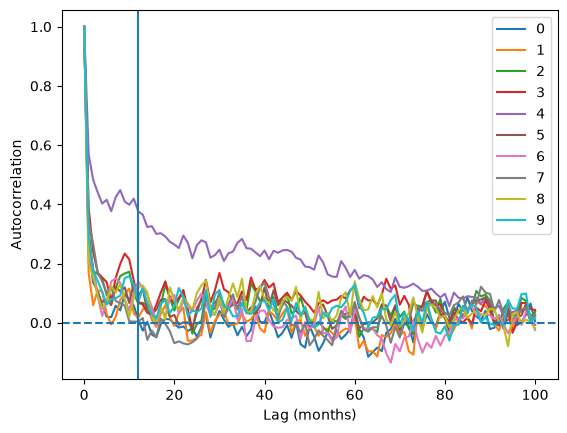

In [89]:
# at a specific latitude; what is the temportal memory of a specific mode 
from statsmodels.tsa.stattools import acf

for mode_number in range(10):
    signal = a_10.isel(mode_right=mode_number, j=15).values

    autocorr = acf(signal, nlags=100, fft=True)

    plt.plot(np.arange(101), autocorr, label=mode_number)
plt.axhline(0, linestyle="--")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.axvline(x = 12)
plt.legend()
plt.show()

for mode_number in range(10):
    signal = a_10.isel(mode_right=mode_number, j=1).values

    autocorr = acf(signal, nlags=100, fft=True)

    plt.plot(np.arange(101), autocorr, label=mode_number)
plt.axhline(0, linestyle="--")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.axvline(x = 12)
plt.legend()
plt.show()

for mode_number in range(10):
    signal = a_10.isel(mode_right=mode_number, j=30).values

    autocorr = acf(signal, nlags=100, fft=True)

    plt.plot(np.arange(101), autocorr, label=mode_number)
plt.axhline(0, linestyle="--")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.axvline(x = 12)
plt.legend()
plt.show()

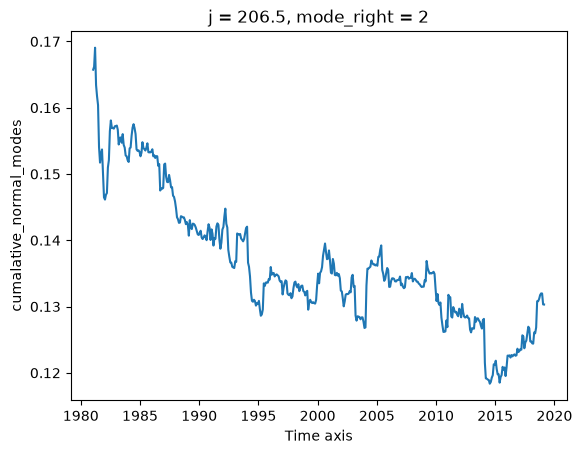

In [94]:
signal = a_10.isel(mode_right=1, j=15)

rolling_std = signal.rolling(
    time_counter=120,
    center=True
).std()

rolling_std.plot()

In [89]:
###
# projecting streamfunction onto basis
###

results = []

for j_idx in ds_psi.j.values:
    V = Psi.sel(j=j_idx).transpose("k", "time_counter")

    # Make the vertical coordinate labels physical depth
    # so they match B_xr.
    V = V.assign_coords(k=V.depthv)

    # Apply vertical weighting matrix
    w = B_xr @ V

    # Make the output vertical coordinate physical depth
    # and rename it to match the eigenvector dimension.
    w = w.assign_coords(k2=z).rename({"k2": "k"})

    # Project onto the normal modes
    a = xr.dot(eigvecs_T_xr, w, dims="k")

    a = a.expand_dims(j=[j_idx])
    results.append(a)

a_all = xr.concat(results, dim="j")

print("a_all dims:", a_all.dims)
print("a_all shape:", a_all.shape)


###
# perturbation streamfunction
###

Psi_prime = Psi - Psi.mean(dim="time_counter")

results_prime = []

for j_idx in ds_psi.j.values:
    V_prime = Psi_prime.sel(j=j_idx).transpose("k", "time_counter")

    # Make the vertical coordinate labels physical depth
    # so they match B_xr.
    V_prime = V_prime.assign_coords(k=V_prime.depthv)

    # Apply vertical weighting matrix
    w_prime = B_xr @ V_prime

    # Make the output vertical coordinate physical depth
    # and rename it to match the eigenvector dimension.
    w_prime = w_prime.assign_coords(k2=z).rename({"k2": "k"})

    # Project the perturbation onto the normal modes
    a_prime = xr.dot(eigvecs_T_xr, w_prime, dims="k")

    a_prime = a_prime.expand_dims(j=[j_idx])
    results_prime.append(a_prime)

a_prime_all = xr.concat(results_prime, dim="j")

print("a_prime_all dims:", a_prime_all.dims)
print("a_prime_all shape:", a_prime_all.shape)

a_all dims: ('j', 'mode', 'time_counter')
a_all shape: (30, 75, 49)
a_prime_all dims: ('j', 'mode', 'time_counter')
a_prime_all shape: (30, 75, 49)
